In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
df_prehension = pd.read_csv("../../data/02_processed/prehension_master_dataset.csv")

leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']

In [ ]:
kinematic_features = df_prehension.select_dtypes(include=np.number).columns.tolist()
identifiers = ['subjName', 'trialN']
kinematic_features = [col for col in kinematic_features if col not in identifiers]

curated_features = [
    feat for feat in kinematic_features
    if not any(pattern in feat for pattern in leaky_patterns)
]

print(f"Original number of features: {len(kinematic_features)}")
print(f"Number of curated (non-leaky) features: {len(curated_features)}")
print("\nFirst 10 curated features:", curated_features[:10])


Original number of features: 173
Number of curated (non-leaky) features: 83

First 10 curated features: ['clear.logMAR', 'mono.logMAR', 'bino.logMAR', 'clear.logCS', 'mono.logCS', 'bino.logCS', 'clear.disparity', 'mono.disparity', 'bino.disparity', 'FVel']


In [ ]:
# Save this curated feature set for future use
curated_df = df_prehension[curated_features + ['distance', 'subjName']]
curated_df.to_csv("../../data/03_features/prehension_curated_features.csv", index=False)

# Re Run the Supervised Model on Curated Data

In [8]:
# Prepare data for the model
X_curated = df_prehension[curated_features]
y_supervised = df_prehension['distance']
groups = df_prehension['subjName']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)


In [9]:
# Define the pipeline
pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Use GroupKFold for subject-aware splitting
group_kfold = GroupKFold(n_splits=5) 

print("\nPerforming 5-fold subject-aware cross-validation on CURATED features...")
cv_scores = cross_val_score(pipeline, X_curated, y_encoded, cv=group_kfold, groups=groups)

print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")



Performing 5-fold subject-aware cross-validation on CURATED features...

Cross-validation accuracy scores: [0.97682709 0.99295775 0.99119718 0.98765432 0.99644128]
Mean CV Accuracy: 0.9890 (+/- 0.0067)


# Analyse the new features

In [ ]:

pipeline.fit(X_curated, y_encoded)
rf_model = pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# Create a DataFrame for visualisation
feature_importance_df = pd.DataFrame({
    'feature': curated_features,
    'importance': importances
}).sort_values('importance', ascending=False)


C:\Users\bharg\AppData\Local\Temp\ipykernel_10364\2765456945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


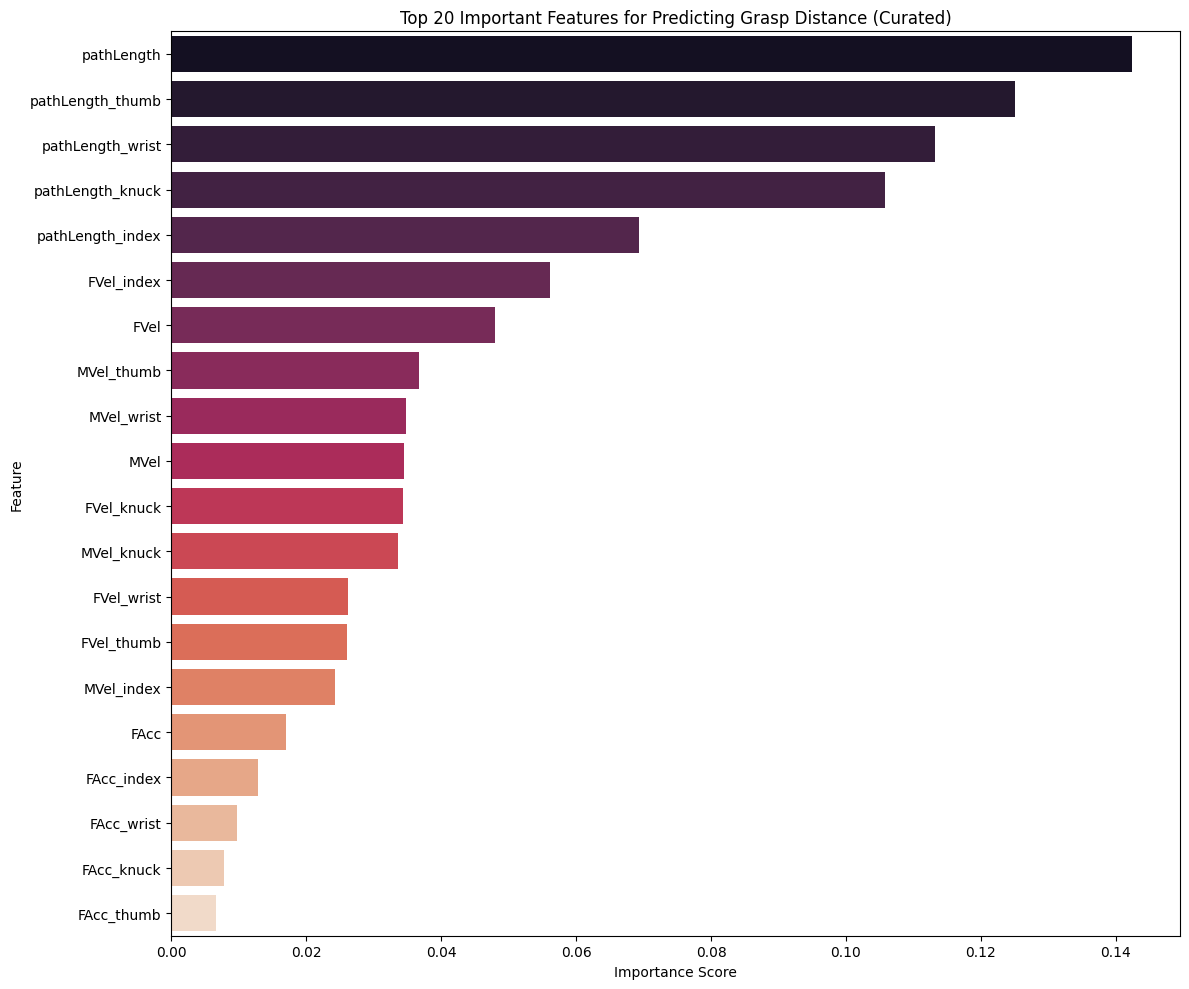


Top 10 most important features (CURATED):
             feature  importance
17        pathLength    0.142392
57  pathLength_thumb    0.125115
58  pathLength_wrist    0.113244
56  pathLength_knuck    0.105747
55  pathLength_index    0.069381
39        FVel_index    0.056060
9               FVel    0.047956
53        MVel_thumb    0.036722
54        MVel_wrist    0.034787
11              MVel    0.034459


In [12]:
# Plot the new importances
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Important Features for Predicting Grasp Distance (Curated)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("../../results/figures/prehension_curated_feature_importance.png")
plt.show()

print("\nTop 10 most important features (CURATED):")
print(feature_importance_df.head(10))


# Refining Aiming Dataset

In [6]:
df_aiming = pd.read_csv("../../data/02_processed/aiming_master_dataset.csv")

In [7]:
# Define leaky features
leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']
kinematic_features_aiming = df_aiming.select_dtypes(include=np.number).columns.tolist()
identifiers = ['subjName', 'trialN']
kinematic_features_aiming = [col for col in kinematic_features_aiming if col not in identifiers]


In [8]:
# Create the curated feature list
curated_features_aiming = [
    feat for feat in kinematic_features_aiming
    if not any(pattern in feat for pattern in leaky_patterns)
]

print(f"Aiming - Original number of features: {len(kinematic_features_aiming)}")
print(f"Aiming - Number of curated features: {len(curated_features_aiming)}")

# Prepare data for the model
X_curated_aiming = df_aiming[curated_features_aiming]
y_supervised_aiming = df_aiming['distance']
groups_aiming = df_aiming['subjName']

# Encode the target variable
le_aiming = LabelEncoder()
y_encoded_aiming = le_aiming.fit_transform(y_supervised_aiming)


Aiming - Original number of features: 205
Aiming - Number of curated features: 97


In [9]:
# Define the pipeline
pipeline_aiming = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])


In [10]:
# Cross-validation
group_kfold = GroupKFold(n_splits=5) 
cv_scores_aiming = cross_val_score(pipeline_aiming, X_curated_aiming, y_encoded_aiming, cv=group_kfold, groups=groups_aiming)

print(f"\nAiming - Curated CV Accuracy Scores: {cv_scores_aiming}")
print(f"Aiming - Mean Curated CV Accuracy: {np.mean(cv_scores_aiming):.4f} (+/- {np.std(cv_scores_aiming):.4f})")



Aiming - Curated CV Accuracy Scores: [1.         0.99274047 0.98312236 0.97652582 0.99765258]
Aiming - Mean Curated CV Accuracy: 0.9900 (+/- 0.0089)


C:\Users\bharg\AppData\Local\Temp\ipykernel_11756\514903501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df_aiming.head(20), palette='rocket')


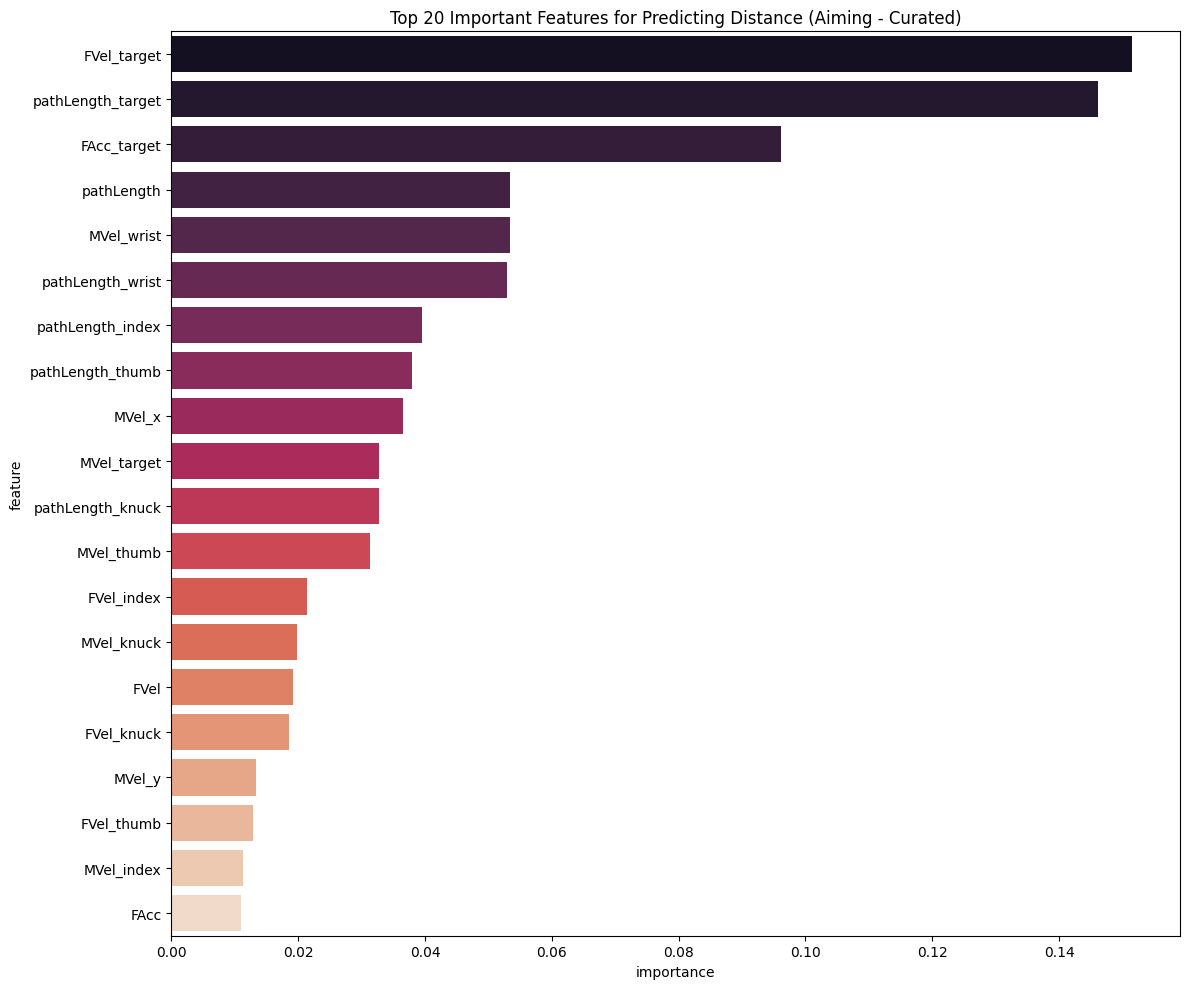

In [11]:
# Feature Importance
pipeline_aiming.fit(X_curated_aiming, y_encoded_aiming)
importances_aiming = pipeline_aiming.named_steps['classifier'].feature_importances_
feature_importance_df_aiming = pd.DataFrame({
    'feature': curated_features_aiming,
    'importance': importances_aiming
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df_aiming.head(20), palette='rocket')
plt.title('Top 20 Important Features for Predicting Distance (Aiming - Curated)')
plt.tight_layout()
plt.savefig("../../results/figures/aiming_curated_feature_importance.png")
plt.show()

# Refine Visual Illusions

In [12]:
df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")


In [13]:
kinematic_features_illusions = df_illusions.select_dtypes(include=np.number).columns.tolist()
kinematic_features_illusions = [col for col in kinematic_features_illusions if col not in identifiers and col not in ['targetSize']]

curated_features_illusions = [
    feat for feat in kinematic_features_illusions
    if not any(pattern in feat for pattern in leaky_patterns)
]

print(f"Illusions - Original number of features: {len(kinematic_features_illusions)}")
print(f"Illusions - Number of curated features: {len(curated_features_illusions)}")


Illusions - Original number of features: 164
Illusions - Number of curated features: 74


In [14]:
# Prepare data
X_curated_illusions = df_illusions[curated_features_illusions]
y_supervised_illusions = df_illusions['illusion']
groups_illusions = df_illusions['subjName']

# Encode
le_illusions = LabelEncoder()
y_encoded_illusions = le_illusions.fit_transform(y_supervised_illusions)

# Pipeline
pipeline_illusions = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

In [15]:
# CV
cv_scores_illusions = cross_val_score(pipeline_illusions, X_curated_illusions, y_encoded_illusions, cv=group_kfold, groups=groups_illusions)

print(f"\nIllusions - Curated CV Accuracy Scores: {cv_scores_illusions}")
print(f"Illusions - Mean Curated CV Accuracy: {np.mean(cv_scores_illusions):.4f} (+/- {np.std(cv_scores_illusions):.4f})")



Illusions - Curated CV Accuracy Scores: [0.77160494 0.64814815 0.70897833 0.7571885  0.65740741]
Illusions - Mean Curated CV Accuracy: 0.7087 (+/- 0.0502)


C:\Users\bharg\AppData\Local\Temp\ipykernel_11756\369733466.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df_illusions.head(20), palette='rocket')


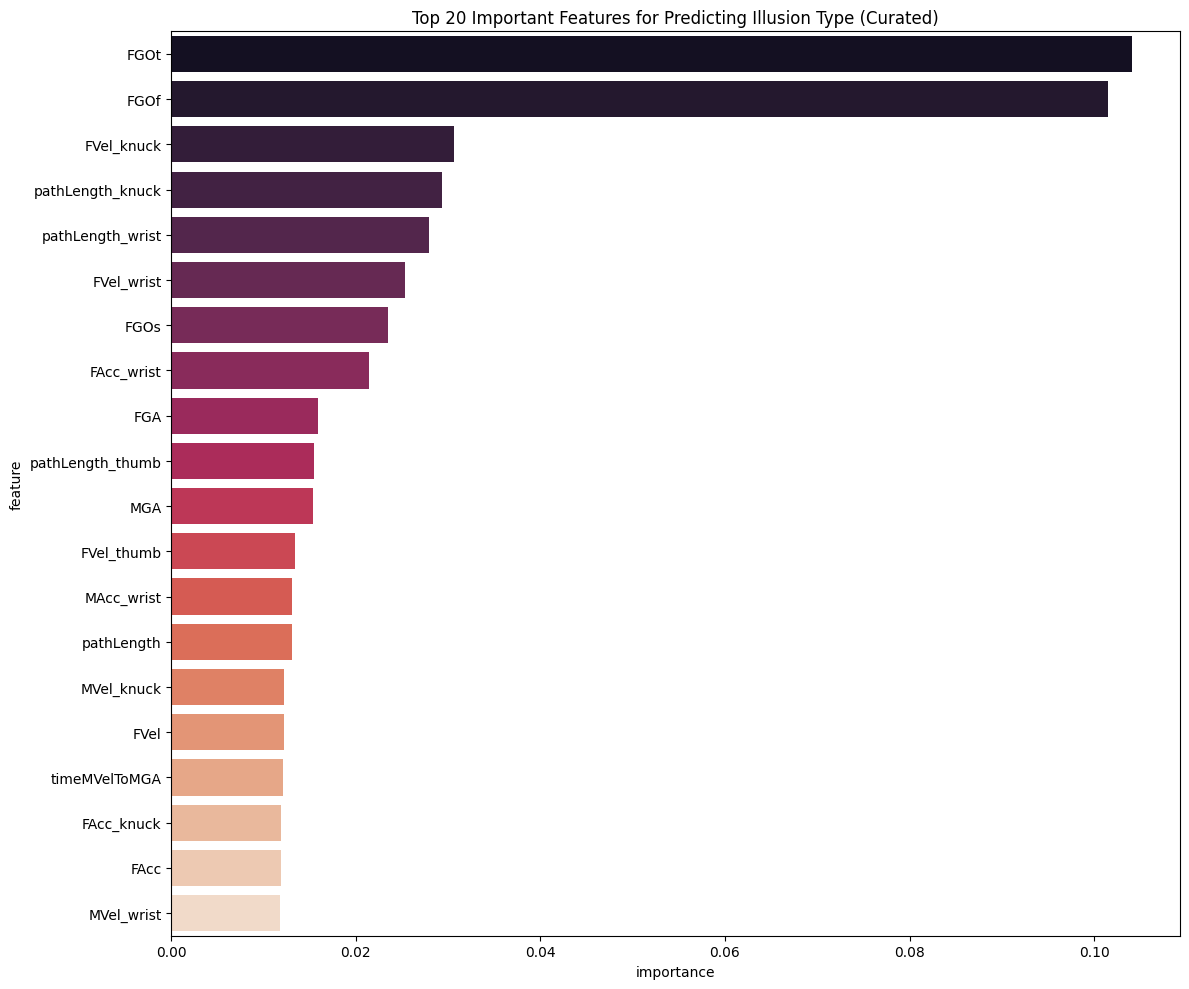

In [16]:
# Feature Importance
pipeline_illusions.fit(X_curated_illusions, y_encoded_illusions)
importances_illusions = pipeline_illusions.named_steps['classifier'].feature_importances_
feature_importance_df_illusions = pd.DataFrame({
    'feature': curated_features_illusions,
    'importance': importances_illusions
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df_illusions.head(20), palette='rocket')
plt.title('Top 20 Important Features for Predicting Illusion Type (Curated)')
plt.tight_layout()
plt.savefig("../../results/figures/illusions_curated_feature_importance.png")
plt.show()
